In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
count = pd.read_csv('final_12.csv').drop('Unnamed: 0',axis=1)
name = ['YYYYMM','DAY','Weekday']
huborzone_temp = np.array([' EWR', 'ZFW', 'ZAB', 'ZMP', ' TPA', 'ZBW', 'ZSE', ' PHL', 'ZAN',
       ' DCA', ' IAH', ' CLT', ' ATL', 'ZDV', ' ORD', 'ZOB', ' MIA',
       ' AUS', ' MDW', ' LAX', ' LAS', 'ZOA', 'ZLC', 'ZME', 'ZID', 'ZKC',
       ' MCO', ' BWI', ' IAD', ' SAN', ' FLL', 'ZHN', ' JFK', ' LGA'])
for i in huborzone_temp:
    name.append(i+'CX_rate')
    name.append(i+'arr_delay')
    name.append(i+'dep_delay')
    name.append(i+'air_delay')
name.append('labels')
count = count[name]
count


,YYYYMM,DAY,Weekday,EWRCX_rate,EWRarr_delay,EWRdep_delay,EWRair_delay,ZFWCX_rate,ZFWarr_delay,ZFWdep_delay,...,ZHNair_delay,JFKCX_rate,JFKarr_delay,JFKdep_delay,JFKair_delay,LGACX_rate,LGAarr_delay,LGAdep_delay,LGAair_delay,labels
0,201001,1,6,0.010057,558.155425,774.925287,4.900293,0.027805,579.823045,678.249493,...,1.150000,0.009107,917.907749,1267.186813,5.571956,0.048485,455.312236,522.764957,4.181435,1
1,201001,2,7,0.052288,3084.149171,2232.203857,2.497238,0.038693,922.043750,1044.833158,...,1.109635,0.051693,2468.366038,2596.790262,7.332075,0.044492,1420.693333,1024.650442,3.244444,7
2,201001,3,1,0.115702,4232.177083,3715.221918,2.221354,0.026906,1062.615385,1120.966086,...,2.320557,0.112026,3614.070896,3908.634686,3.634328,0.111756,3461.574675,2531.230263,4.457792,5
3,201001,4,2,0.068433,1658.417476,1968.143519,4.024272,0.031061,855.781834,930.728406,...,1.575000,0.063047,1274.732342,1342.327068,4.646840,0.024896,742.005666,585.286932,3.818697,11
4,201001,5,3,0.020681,1097.935484,1233.266169,2.682382,0.018437,548.689346,642.403038,...,1.358779,0.000000,466.717842,646.658333,4.248963,0.024161,467.592287,330.052198,4.341598,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,7,0.009223,1533.669333,905.729443,2.917333,0.003147,955.827014,1034.290221,...,1.207254,0.003676,706.073801,476.457565,4.154982,0.011561,689.482353,598.604651,2.050980,1
4865,202407,28,1,0.035714,3150.793893,1977.384615,2.735369,0.005547,1174.373978,1398.392857,...,1.215385,0.001742,589.710801,645.944056,3.118467,0.001435,885.324786,718.434783,3.566952,7
4866,202407,29,2,0.012225,2401.731343,1612.167488,2.564677,0.007016,985.710253,1038.540581,...,1.167089,0.006969,1303.151408,1063.006993,4.288732,0.005195,1258.590078,911.906005,3.861619,7
4867,202407,30,3,0.094203,2771.992000,1687.680000,3.778667,0.013884,1110.789954,1233.059361,...,1.242347,0.005282,2416.957447,1738.727915,8.471631,0.018349,1684.968085,1190.991957,3.242021,7


In [5]:
name = []
for i in huborzone_temp:
    name.append(i+'CX_rate')
    name.append(i+'arr_delay')
    name.append(i+'dep_delay')
    name.append(i+'air_delay')
len(name)

136

In [6]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(count[name])

# Apply PCA
pca = PCA(n_components=30, random_state=42)
principal_components = pca.fit_transform(x_scaled)

# Create DataFrame for the principal components
pca_df = pd.DataFrame(data=principal_components)


# Print the explained variance
explained_variance = pca.explained_variance_ratio_
explained_variance_sum = sum(explained_variance)
print(explained_variance_sum,f'Explained Variance: {explained_variance}')

loadings = pca.components_

# Create a DataFrame for better readability
loadings_df = pd.DataFrame(loadings, )

0.8266169257058854 Explained Variance: [0.29974789 0.07971556 0.06904337 0.04566406 0.03845581 0.02998146
 0.02260498 0.02034677 0.01972247 0.01680747 0.01575427 0.01494407
 0.01322183 0.01242941 0.0106929  0.01048339 0.01026978 0.00911133
 0.00890446 0.00881059 0.00817304 0.00791163 0.00742497 0.00735347
 0.00699173 0.00685075 0.00661529 0.00653092 0.00606108 0.00599219]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate synthetic 4-dimensional time series data
np.random.seed(42)
time = range(len(count))



# Convert data into a DataFrame
df = pca_df.iloc[:,:24]
df['time'] = time
print(len(df.iloc[0]))

# Initialize and fit the Isolation Forest model
model = IsolationForest(contamination=164/4869, random_state=42)
model.fit(pca_df.iloc[:,:24])
print(len(pca_df.iloc[:,:24].iloc[0]))

# Predict anomalies
df['anomaly'] = model.predict(pca_df.iloc[:,:24])

# -1 for anomaly, 1 for normal
anomalies = df[df['anomaly'] == -1]



25
24


/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/989769166.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = time
/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/989769166.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly'] = model.predict(pca_df.iloc[:,:24])


In [10]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# Sample Data (randomly generated for demonstration)
#X = np.random.rand(100, 2)

# Initialize the Isolation Forest
iso_forest = IsolationForest(contamination=383/4869, random_state=42)

# Fit the model to the data
iso_forest.fit(pca_df.iloc[:,:24])

# Get the raw anomaly score
anomaly_scores = iso_forest.decision_function(pca_df.iloc[:,:24])

# Rescale the anomaly scores to be between 0 and 1
scaler = MinMaxScaler()
anomaly_scores_scaled = scaler.fit_transform(anomaly_scores.reshape(-1, 1))

# Output
print("Raw Anomaly Scores:\n", anomaly_scores[:5])  # first 5 scores
print("Scaled Anomaly Scores (0 to 1):\n", anomaly_scores_scaled[:5])  # first 5 scores


Raw Anomaly Scores:
 [0.12737887 0.11914834 0.09287622 0.1292815  0.11451254]
Scaled Anomaly Scores (0 to 1):
 [[0.92976713]
 [0.90713574]
 [0.83489563]
 [0.93499878]
 [0.89438875]]


In [11]:
df['anomaly'] = df['anomaly']<0

/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/3937743298.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly'] = df['anomaly']<0


In [12]:
df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,time,anomaly
0,-2.210313,-0.683128,1.209149,0.741712,0.349108,1.531934,-0.440146,1.597781,-0.337346,0.165049,...,-0.249479,-0.791918,-0.827153,-0.388400,-0.655567,0.782950,-1.057291,0.014025,0,False
1,4.666468,-1.089737,-1.397503,2.184368,-1.666554,-0.827497,-1.479873,0.970029,-0.890683,0.992250,...,0.439250,-0.591121,-1.854497,0.723920,-1.069098,0.122048,-0.889266,0.327162,1,False
2,7.296955,-3.957857,-2.697423,0.940441,-1.009541,-0.752922,-2.618785,2.563124,-1.728355,-0.207333,...,0.263747,-2.176579,-0.824491,1.335260,-1.313368,-0.737014,-1.291855,0.793969,2,False
3,1.282399,-0.602681,-0.156426,0.644340,-1.148123,-0.220956,-1.267336,1.923612,0.489181,-1.019485,...,-0.954126,-0.506499,-1.182396,0.583575,-1.495259,0.683949,-0.307114,0.106344,3,False
4,-1.925256,-0.302181,0.602777,-0.455017,-2.001319,0.567451,-0.291322,1.216773,0.279432,-0.641546,...,-0.552132,-1.244351,-1.874476,0.909201,-1.363021,1.311690,0.669550,0.039547,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,-0.928415,0.761757,-2.459650,-0.689128,0.816792,0.754510,-0.428036,-0.525693,0.175424,0.455782,...,-0.152637,-0.097311,0.404720,-0.499359,-0.946241,0.193142,-1.071093,0.903012,4864,False
4865,4.937723,1.635519,-5.085908,-1.403197,0.800335,1.540921,-1.358492,-0.567852,1.921266,0.479950,...,-0.185365,-0.109215,1.504847,-0.112150,-0.763554,-0.203170,-0.611676,0.713794,4865,False
4866,6.188043,0.135560,-5.793889,-1.451424,0.051831,1.838126,-0.385079,0.112809,3.288081,0.783154,...,0.831170,-0.032353,0.658282,1.217167,-1.336396,-0.593181,0.107063,-0.683135,4866,False
4867,4.065097,-1.330488,-4.154635,-1.577954,0.131555,-0.306596,0.562212,-0.376020,2.171173,0.036795,...,0.275242,0.179677,0.444685,0.920927,-0.751686,-0.376864,-0.628653,-0.438969,4867,False


In [13]:
df['anomaly'].value_counts()

False    4705
True      164
Name: anomaly, dtype: int64

In [14]:
df['anomaly_scores'] = anomaly_scores
df['anomaly_scores_scaled'] = anomaly_scores_scaled

/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/2926757651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_scores'] = anomaly_scores
/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/2926757651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_scores_scaled'] = anomaly_scores_scaled


In [15]:
df['anomaly_scores_scaled'] = 1-df['anomaly_scores_scaled']

/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/4166015663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_scores_scaled'] = 1-df['anomaly_scores_scaled']


In [17]:
df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,time,anomaly,anomaly_scores,anomaly_scores_scaled
0,-2.210313,-0.683128,1.209149,0.741712,0.349108,1.531934,-0.440146,1.597781,-0.337346,0.165049,...,-0.827153,-0.388400,-0.655567,0.782950,-1.057291,0.014025,0,False,0.127379,0.070233
1,4.666468,-1.089737,-1.397503,2.184368,-1.666554,-0.827497,-1.479873,0.970029,-0.890683,0.992250,...,-1.854497,0.723920,-1.069098,0.122048,-0.889266,0.327162,1,False,0.119148,0.092864
2,7.296955,-3.957857,-2.697423,0.940441,-1.009541,-0.752922,-2.618785,2.563124,-1.728355,-0.207333,...,-0.824491,1.335260,-1.313368,-0.737014,-1.291855,0.793969,2,False,0.092876,0.165104
3,1.282399,-0.602681,-0.156426,0.644340,-1.148123,-0.220956,-1.267336,1.923612,0.489181,-1.019485,...,-1.182396,0.583575,-1.495259,0.683949,-0.307114,0.106344,3,False,0.129282,0.065001
4,-1.925256,-0.302181,0.602777,-0.455017,-2.001319,0.567451,-0.291322,1.216773,0.279432,-0.641546,...,-1.874476,0.909201,-1.363021,1.311690,0.669550,0.039547,4,False,0.114513,0.105611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,-0.928415,0.761757,-2.459650,-0.689128,0.816792,0.754510,-0.428036,-0.525693,0.175424,0.455782,...,0.404720,-0.499359,-0.946241,0.193142,-1.071093,0.903012,4864,False,0.138352,0.040060
4865,4.937723,1.635519,-5.085908,-1.403197,0.800335,1.540921,-1.358492,-0.567852,1.921266,0.479950,...,1.504847,-0.112150,-0.763554,-0.203170,-0.611676,0.713794,4865,False,0.102255,0.139316
4866,6.188043,0.135560,-5.793889,-1.451424,0.051831,1.838126,-0.385079,0.112809,3.288081,0.783154,...,0.658282,1.217167,-1.336396,-0.593181,0.107063,-0.683135,4866,False,0.105413,0.130633
4867,4.065097,-1.330488,-4.154635,-1.577954,0.131555,-0.306596,0.562212,-0.376020,2.171173,0.036795,...,0.444685,0.920927,-0.751686,-0.376864,-0.628653,-0.438969,4867,False,0.122953,0.082402


In [19]:
df['labels'] = list(count['labels'])

/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/2594245389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['labels'] = list(count['labels'])


In [20]:
df['labels'] = df['labels']+1

/var/folders/pd/42djns7x589bw787p86syckm0000gn/T/ipykernel_35868/2807787902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['labels'] = df['labels']+1


In [11]:
df.groupby('labels').mean()[['anomaly_scores_scaled']].sort_values('anomaly_scores_scaled')

,anomaly_scores_scaled
labels,
9,0.065856
2,0.071781
11,0.083289
12,0.124510
8,0.150528
7,0.219970
4,0.235628
1,0.242562
10,0.304292


In [21]:
df.groupby('labels').mean()[['anomaly_scores_scaled']].sort_values('anomaly_scores_scaled')

,anomaly_scores_scaled
labels,
9,0.066746
2,0.126254
11,0.140973
12,0.148383
8,0.190894
6,0.296322
4,0.332566
7,0.370214
1,0.407996


In [22]:
# Generate random data (you can replace this with your own data)
data = df['anomaly_scores_scaled']

# Sort the data
sorted_data = np.sort(data)

# Calculate the cumulative probabilities
cdf = np.linspace(0, 1, len(sorted_data))

In [28]:
temp1 = pd.DataFrame()
temp1['anomaly_scores_scaled'] = sorted_data
temp1['cdf'] = cdf

In [29]:
df = df.merge(temp1,on = 'anomaly_scores_scaled')

In [23]:
color_map = pd.DataFrame()
color_map['labels'] = range(1,13)
color_map['colors'] = ['red', 'orange', 'yellow', 'green', 'cyan', 'blue', 'indigo', 'violet', 'pink', 'magenta', 'lime', 'teal']


In [24]:
df = df.merge(color_map,on = ['labels'])

In [25]:
sorted_data

array([0.00000000e+00, 4.72613411e-04, 1.03578384e-03, ...,
       9.48664755e-01, 9.72600855e-01, 1.00000000e+00])

In [26]:
cdf

array([0.00000000e+00, 2.05423172e-04, 4.10846343e-04, ...,
       9.99589154e-01, 9.99794577e-01, 1.00000000e+00])

In [31]:
color_map['meaning'] = ['West Disturbance','Smooth2','East Super Disruption','ORD Disturbance',
                       'NAS Disruption','North East Disruption','DFW Disturbance','NAS Slightly Disturbance',
                       'Smooth1','South East Disturbance','Almost Smooth','East Slightly Disturbance']

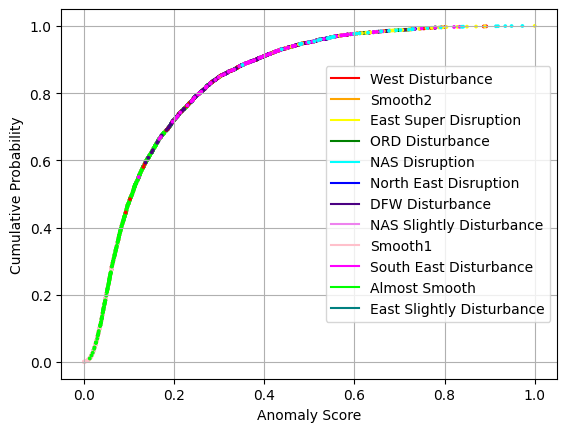

In [32]:
plt.scatter(df['anomaly_scores_scaled'], df['cdf'],c = df['colors'],s = 3)
for i in range(12):
    plt.plot([0.6], [i/24],c = color_map.iloc[i]['colors'],label = color_map.iloc[i]['meaning'])
plt.xlabel('Anomaly Score')
plt.ylabel('Cumulative Probability')
plt.legend()
#plt.title('Cumulative Distribution Function (CDF)')
plt.grid(True)
plt.show()

In [33]:
color_map = pd.DataFrame()
color_map['labels'] = range(1,13)
color_map['colors'] = ['orange', 'green', 'red', 'orange', 'red', 'blue', 'orange', 'green', 'green', 'blue', 'green', 'green']

In [34]:
temp1 = pd.DataFrame()
temp1['anomaly_scores_scaled'] = sorted_data
temp1['cdf'] = cdf

In [35]:
df = df.merge(color_map,on = ['labels'])

In [36]:
df = df.merge(temp1,on = 'anomaly_scores_scaled')

In [37]:
plt.scatter(df['anomaly_scores_scaled'], df['cdf'],c = df['colors'],s = 3)
names = ['green','orange','blue','red']
name = ['Smooth','Regional Disturbance','Regional Disruption','NAS Disruption']
for i in range(4):
    plt.plot([0.6], [i/8],c = names[i],label=name[i])
plt.xlabel('Anomaly Score')
plt.ylabel('Cumulative Probability')
plt.legend()
#plt.title('Cumulative Distribution Function (CDF)')
plt.grid(True)
plt.show()

KeyError: 'cdf'